# Efficient Portfolio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
my_data = pd.read_csv("data.csv")
my_data = my_data.drop(columns=['gvkey'])
my_data = my_data[['datadate', 'tic', 'prccd']]

In [20]:
soxx = my_data[my_data['tic'] == 'SOXX']
srvr = my_data[my_data['tic'] == 'SRVR']
xlf = my_data[my_data['tic'] == 'XLF']
xli = my_data[my_data['tic'] == 'XLI']
xlk = my_data[my_data['tic'] == 'XLK']
xlp = my_data[my_data['tic'] == 'XLP']
xlre = my_data[my_data['tic'] == 'XLRE']
xlu = my_data[my_data['tic'] == 'XLU']
print("Data Lengths",
      "\nSOXX:", len(soxx),
      "\nSRVR:", len(srvr),
      "\nXLF:", len(xlf),
      "\nXLI:", len(xli),
      "\nXLK:", len(xlk),
      "\nXLP:", len(xlp),
      "\nXLRE:", len(xlre),
      "\nXLU:", len(xlu))
print("SRVR and XLRE have less data. SRVR's inception date was May 15, 2018 and XLRE's was October 7, 2015.")

Data Lengths 
SOXX: 5463 
SRVR: 2098 
XLF: 5463 
XLI: 5463 
XLK: 5463 
XLP: 5463 
XLRE: 2753 
XLU: 5463
SRVR and XLRE have less data. SRVR's inception date was May 15, 2018 and XLRE's was October 7, 2015.


In [28]:
# Join prices on date and drop NaN values
my_data['datadate'] = pd.to_datetime(my_data['datadate'])
prices = my_data.pivot(
    index='datadate',
    columns='tic',
    values='prccd'
)
prices = prices.dropna()

Text(0, 0.5, 'Price')

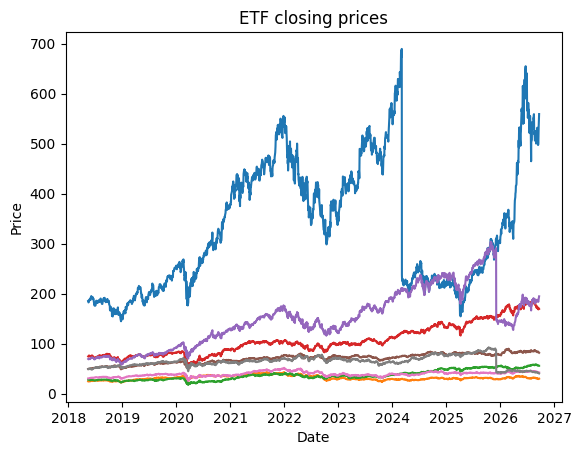

In [29]:
plt.plot(prices)
plt.title('ETF closing prices')
plt.xlabel('Date')
plt.ylabel('Price')

Sharp peaks and troughs on the graph represent SOXX's 3 for 1 stock split on March 7, 2024 and both XLK and XLU's 2 for 1 split on December 5, 2025.

Text(0, 0.5, 'Price')

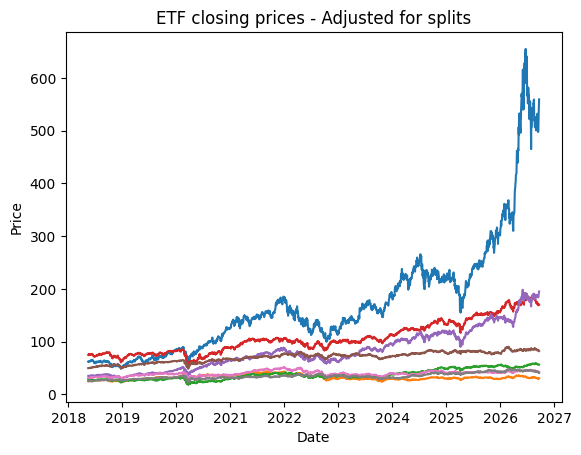

In [30]:
prices.loc[prices.index < '2024-03-07', 'SOXX'] /= 3
prices.loc[prices.index < '2025-12-05', 'XLK'] /= 2
prices.loc[prices.index < '2025-12-05', 'XLU'] /= 2

plt.plot(prices)
plt.title('ETF closing prices - Adjusted for splits')
plt.xlabel('Date')
plt.ylabel('Price')

In [35]:
returns = prices.pct_change().dropna() # Returns with SOXX & SRVR
returns_noai = returns.drop(columns=['SOXX', 'SRVR']) # Returns without SOXX & SRVR

## Covariance Matrix without AI


In [37]:
mean_returns_noai = returns_noai.mean()
std_returns_noai = returns_noai.std()
cov_matrix_noai = returns_noai.cov()
cov_matrix_noai

tic,XLF,XLI,XLK,XLP,XLRE,XLU
tic,,,,,,
XLF,0.000212,0.000168,0.000155,0.000087,0.000134,0.000100
XLI,0.000168,0.000179,0.000162,0.000081,0.000127,0.000099
XLK,0.000155,0.000162,0.000282,0.000074,0.000124,0.000086
XLP,0.000087,0.000081,0.000074,0.000097,0.000093,0.000088
XLRE,0.000134,0.000127,0.000124,0.000093,0.000187,0.000131
XLU,0.000100,0.000099,0.000086,0.000088,0.000131,0.000164


## Covariance Matrix with AI


In [38]:
mean_returns = returns.mean()
std_returns = returns.std()
cov_matrix = returns.cov()
cov_matrix

tic,SOXX,SRVR,XLF,XLI,XLK,XLP,XLRE,XLU
tic,,,,,,,,
SOXX,0.000542,0.000167,0.000184,0.000208,0.000350,0.000071,0.000136,0.000088
SRVR,0.000167,0.000183,0.000112,0.000116,0.000141,0.000080,0.000159,0.000114
XLF,0.000184,0.000112,0.000212,0.000168,0.000155,0.000087,0.000134,0.000100
XLI,0.000208,0.000116,0.000168,0.000179,0.000162,0.000081,0.000127,0.000099
XLK,0.000350,0.000141,0.000155,0.000162,0.000282,0.000074,0.000124,0.000086
XLP,0.000071,0.000080,0.000087,0.000081,0.000074,0.000097,0.000093,0.000088
XLRE,0.000136,0.000159,0.000134,0.000127,0.000124,0.000093,0.000187,0.000131
XLU,0.000088,0.000114,0.000100,0.000099,0.000086,0.000088,0.000131,0.000164


In [40]:
returns.describe()

tic,SOXX,SRVR,XLF,XLI,XLK,XLP,XLRE,XLU
count,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000
mean,0.001321,0.000187,0.000432,0.000483,0.000963,0.000287,0.000250,0.000320
std,0.023279,0.013541,0.014575,0.013389,0.016782,0.009847,0.013680,0.012803
min,-0.152278,-0.100542,-0.137093,-0.113441,-0.138140,-0.093956,-0.160011,-0.113577
25%,-0.010679,-0.006770,-0.005898,-0.005635,-0.007334,-0.004406,-0.006241,-0.006035
50%,0.001624,0.000687,0.000772,0.000840,0.001665,0.000527,0.000814,0.000902
75%,0.014205,0.007458,0.007404,0.007294,0.009810,0.005281,0.007096,0.006818
max,0.185716,0.103861,0.131566,0.126512,0.134257,0.085106,0.087800,0.127934


## Efficient Frontier without AI

Text(0, 0.5, 'Expected return')

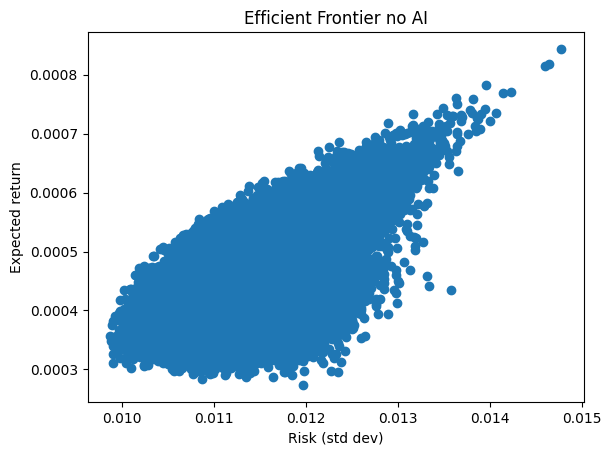

In [45]:
# Generate a bunch of random portfolio weights
n_portfolios = 100000

portfolio_weights = []

for _ in range(n_portfolios):
    weights = np.random.random(6)
    weights = weights / weights.sum()
    portfolio_weights.append(weights)

portfolio_weights_noai = np.array(portfolio_weights)

# Plot return/risk points for each portfolio
portfolio_returns = []
portfolio_risks = []

for weights in portfolio_weights_noai:
    portfolio_return = weights @ mean_returns_noai
    portfolio_variance = weights.T @ cov_matrix_noai @ weights
    portfolio_std = np.sqrt(portfolio_variance)

    portfolio_returns.append(portfolio_return)
    portfolio_risks.append(portfolio_std)

plt.scatter(portfolio_risks, portfolio_returns)
plt.title('Efficient Frontier no AI')
plt.xlabel('Risk (std dev)')
plt.ylabel('Expected return')

## Efficient Frontier with AI

Text(0, 0.5, 'Expected return')

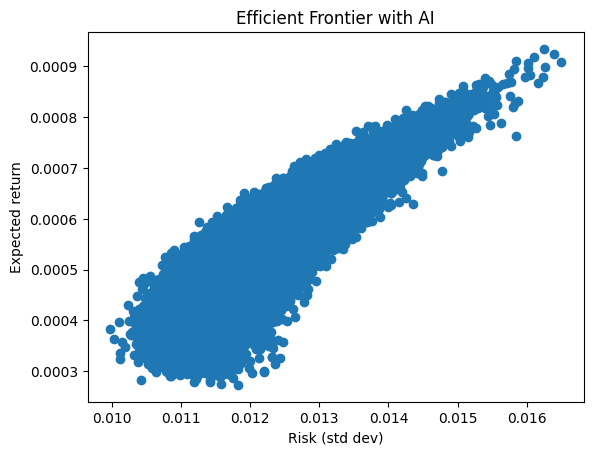

In [46]:
# Generate a bunch of random portfolio weights
portfolio_weights = []

for _ in range(n_portfolios):
    weights = np.random.random(8)
    weights = weights / weights.sum()
    portfolio_weights.append(weights)

portfolio_weights = np.array(portfolio_weights)

# Plot return/risk points for each portfolio
portfolio_returns = []
portfolio_risks = []

for weights in portfolio_weights:
    portfolio_return = weights @ mean_returns
    portfolio_variance = weights.T @ cov_matrix @ weights
    portfolio_std = np.sqrt(portfolio_variance)

    portfolio_returns.append(portfolio_return)
    portfolio_risks.append(portfolio_std)

plt.scatter(portfolio_risks, portfolio_returns)
plt.title('Efficient Frontier with AI')
plt.xlabel('Risk (std dev)')
plt.ylabel('Expected return')